<a href="https://colab.research.google.com/github/Kunal-7O7/Hotel-Booking-Cancellation-Analysis/blob/main/Annomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing Basic Liabrairy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression,Ridge,Lasso
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
data=np.random.seed(42)
normal_data=np.random.normal(0,1,(300,2))
annomaly_data=np.random.uniform(6,2,(10,2))

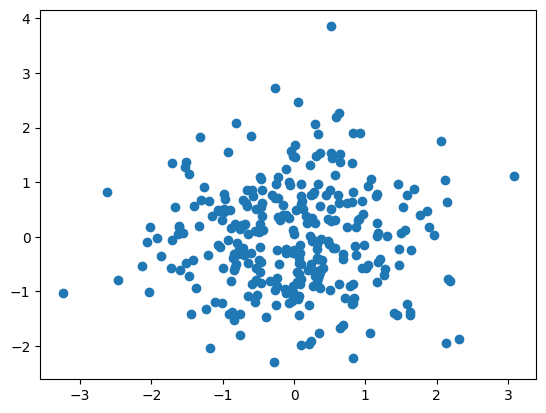

In [3]:
plt.scatter(normal_data[:,0],
            normal_data[:,1])

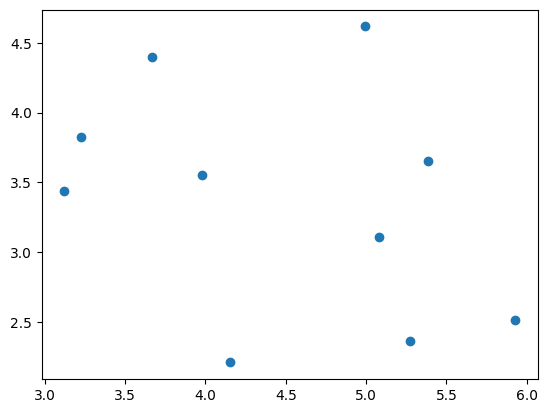

In [4]:
plt.scatter(annomaly_data[:,0],
            annomaly_data[:,1])

In [5]:
# Merging the data poit
df=np.vstack([normal_data,annomaly_data])
df


array([[ 4.96714153e-01, -1.38264301e-01],
       [ 6.47688538e-01,  1.52302986e+00],
       [-2.34153375e-01, -2.34136957e-01],
       [ 1.57921282e+00,  7.67434729e-01],
       [-4.69474386e-01,  5.42560044e-01],
       [-4.63417693e-01, -4.65729754e-01],
       [ 2.41962272e-01, -1.91328024e+00],
       [-1.72491783e+00, -5.62287529e-01],
       [-1.01283112e+00,  3.14247333e-01],
       [-9.08024076e-01, -1.41230370e+00],
       [ 1.46564877e+00, -2.25776300e-01],
       [ 6.75282047e-02, -1.42474819e+00],
       [-5.44382725e-01,  1.10922590e-01],
       [-1.15099358e+00,  3.75698018e-01],
       [-6.00638690e-01, -2.91693750e-01],
       [-6.01706612e-01,  1.85227818e+00],
       [-1.34972247e-02, -1.05771093e+00],
       [ 8.22544912e-01, -1.22084365e+00],
       [ 2.08863595e-01, -1.95967012e+00],
       [-1.32818605e+00,  1.96861236e-01],
       [ 7.38466580e-01,  1.71368281e-01],
       [-1.15648282e-01, -3.01103696e-01],
       [-1.47852199e+00, -7.19844208e-01],
       [-4.

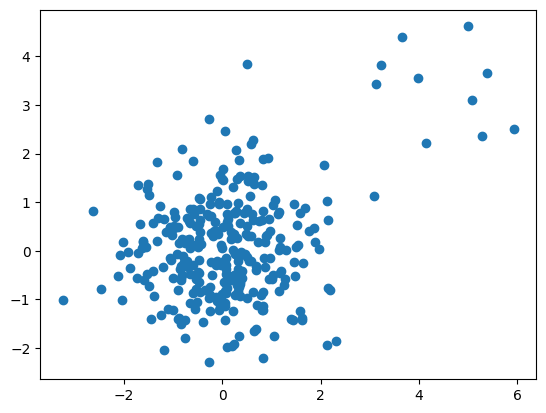

In [6]:
plt.scatter(df[:,0],
            df[:,1])

In [7]:
df.shape

(310, 2)

In [8]:
#building the model
from sklearn.ensemble import IsolationForest

In [9]:
model1=IsolationForest(contamination=0.03,
                       random_state=42)


In [10]:
labels1=model1.fit_predict(df)

In [11]:
counting_annomaly=np.sum(labels1==-1)
print(counting_annomaly)

10


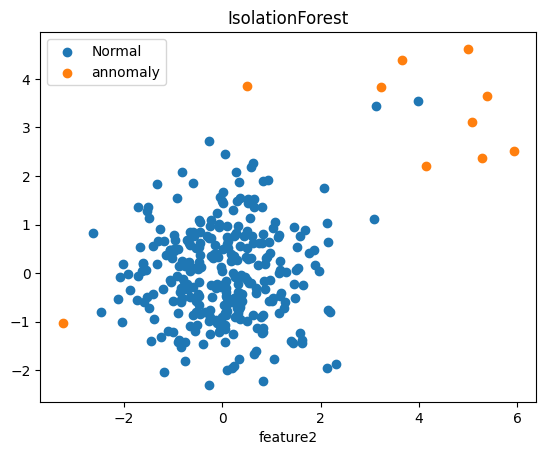

In [12]:
#ploting the datapoints
plt.scatter(df[labels1==1,0],
            df[labels1==1,1],
            label="Normal")

plt.scatter(df[labels1==-1,0],
            df[labels1==-1,1],
            label="annomaly")
plt.title("IsolationForest")
plt.xlabel("feature1")
plt.xlabel("feature2")
plt.legend()
plt.show()

In [14]:
model2=IsolationForest(contamination=0.10,
                       max_samples=5,
                       random_state=42)


In [15]:
labels2=model2.fit_predict(df)

In [22]:
print(np.sum(labels2==-1))

31


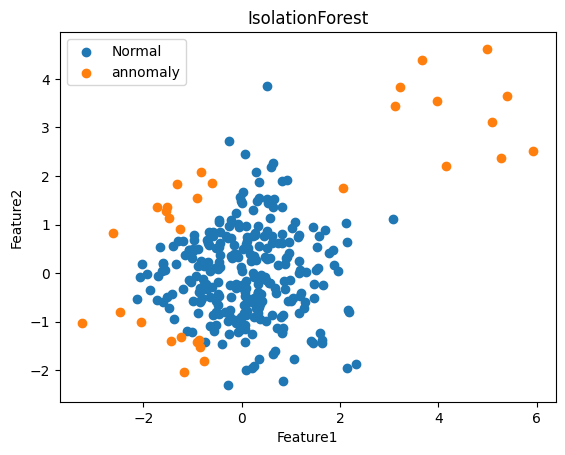

In [26]:
plt.scatter(df[labels2==1,0],
               df[labels2==1,1],
            label="Normal")
plt.scatter(df[labels2==-1,0],
            df[labels2==-1,1],
            label="annomaly")
plt.title("IsolationForest")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.show()

In [27]:
print("decision_model1",model1.decision_function(df))
print("decision_model2",model2.decision_function(df))

decision_model1 [ 0.24409979  0.18641637  0.24110206  0.17939166  0.2412395   0.24027525
  0.11722506  0.17146467  0.22119098  0.17602679  0.18381144  0.18424754
  0.24843288  0.2187861   0.23756999  0.1258212   0.2341446   0.1940794
  0.11349383  0.21118012  0.22294067  0.24798116  0.18481855  0.21512332
  0.13670052  0.25055476  0.23490504  0.21319726  0.23824456  0.22681226
  0.23991133  0.17967286  0.19083164  0.22229046  0.24524482  0.19496916
  0.18521327  0.00494582  0.25530162  0.10296773  0.24404507  0.18232
  0.23927501  0.22569472  0.23825636  0.23041412  0.24309845  0.15499531
  0.24784196  0.25397908  0.19937274  0.23128999  0.24626576  0.15459782
  0.24642126  0.15578705  0.08127916  0.24510578  0.22535306  0.20960786
  0.2094571   0.13159874  0.11557791  0.22077786  0.25013982  0.19322964
  0.22380689  0.13749853  0.23927139  0.19390223  0.20701548  0.19377197
  0.23848825  0.15285667  0.23967899  0.25118094  0.24240512  0.24620183
  0.16035275  0.21050305  0.21158283  0

In [31]:
model3=IsolationForest(contamination=0.10,
                       max_features=2,
                       max_samples=5,
                       n_estimators=100,
                       random_state=42)


In [32]:
labels3=model3.fit_predict(df)

In [33]:
print(np.sum(labels3==-1))

31


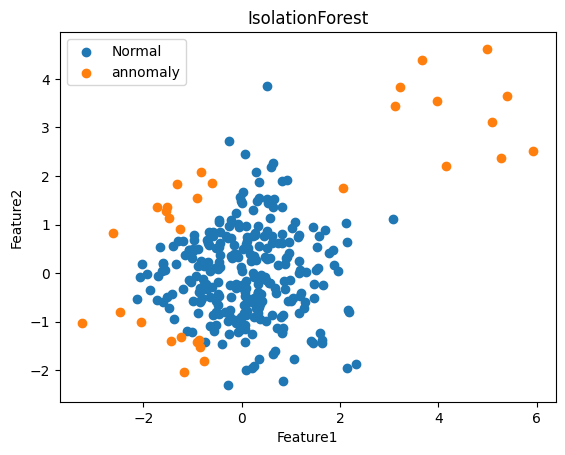

In [34]:
plt.scatter(df[labels3==1,0],
               df[labels3==1,1],
            label="Normal")
plt.scatter(df[labels3==-1,0],
            df[labels3==-1,1],
            label="annomaly")
plt.title("IsolationForest")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.show()